<a href="https://colab.research.google.com/github/ancestor9/2026_Fall_AI-Workflow/blob/main/appendix/Attension_mechanism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [8]:
# @title 1. 가상의 입력 데이터 설정(출력된 텐서(tensor)의 각 행(줄)이 단어 하나를 나타내고, 그 안에 들어있는 6개의 숫자가 6차원 벡터 값)
# 문장 길이(seq_len) = 4 (예: "The", "animal", "is", "tired")
# 각 단어의 임베딩 차원(d_model) = 6
seq_len = 4
d_model = 6

# 가상의 단어 벡터 행렬 (Input X)
# shape: (batch_size=1, seq_len=4, d_model=6)
torch.manual_seed(42)  # 재현성을 위한 난수 고정
X = torch.randn(1, seq_len, d_model)
X

tensor([[[ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345],
         [-0.0431, -1.6047,  0.3559, -0.6866, -0.4934,  0.2415],
         [-1.1109,  0.0915, -2.3169, -0.2168, -0.3097, -0.3957],
         [ 0.8034, -0.6216, -0.5920, -0.0631, -0.8286,  0.3309]]])

In [9]:
# @title 2. Q, K, V 생성을 위한 가중치 행렬(W^Q, W^K, W^V) 정의
# 여기서는 편의상 차원 축소 없이 d_k = d_model (6차원)으로 설정
d_k = d_model
W_Q = nn.Linear(d_model, d_k, bias=False)
W_K = nn.Linear(d_model, d_k, bias=False)
W_V = nn.Linear(d_model, d_k, bias=False)
W_Q

Linear(in_features=6, out_features=6, bias=False)

In [10]:
# @title 3. 입력(X)을 Q, K, V 벡터로 변환 (이미지의 Q', K', V' 단계)
Q = W_Q(X)  # shape: (1, 4, 6)
K = W_K(X)  # shape: (1, 4, 6)
V = W_V(X)  # shape: (1, 4, 6)
Q

tensor([[[-0.1855,  1.1940, -0.2589,  1.0531,  1.0644,  2.0927],
         [-0.1757,  0.2786, -0.6637,  0.5561,  0.4791,  0.2596],
         [-0.6116, -0.4939,  0.0322, -0.3640, -0.7070, -0.9808],
         [-0.2224,  0.3195, -0.6494,  0.2885,  0.0893,  0.2290]]],
       grad_fn=<UnsafeViewBackward0>)

In [12]:
K

tensor([[[-0.6653,  1.1491, -0.0925,  0.1216,  0.6274, -0.5946],
         [-0.3976,  0.2183, -0.1417,  0.5661, -0.0413,  0.2443],
         [ 0.0834, -0.7556, -0.1223, -0.3262,  0.5655,  1.0915],
         [-0.3488, -0.1624, -0.3972, -0.3258, -0.3008, -0.2232]]],
       grad_fn=<UnsafeViewBackward0>)

In [13]:
V

tensor([[[ 0.2075, -0.0592, -0.0094,  0.0768, -0.4422, -0.3686],
         [ 0.4852,  0.4516,  0.3773, -0.5186,  0.6093,  0.3598],
         [ 0.5985,  0.3216,  0.6092,  0.4579,  0.1714, -0.4150],
         [ 0.3333, -0.0486, -0.2845,  0.4313, -0.3260,  0.4006]]],
       grad_fn=<UnsafeViewBackward0>)

- 입력으로 들어온 X ("The", "animal", "is", "tired")는 각 단어의 원래 의미 정보(Embedding Vector)만 담고 있지만 어텐션(Attension)을 하려면 단어 하나가 3가지 역할을 동시에 수행하기 위해

> $Q$ (Query): 다른 단어들에게 물어볼 질문 역할

> $K$ (Key): 다른 단어들의 질문을 받을 식별표(라벨) 역할

> $V$ (Value): 실제로 전달할 내용물 역할

- 원래 단어 벡터 X에 각각의 전용 변환기($W^Q, W^K, W^V$)를 곱해줘서, 하나의 단어에서 $Q, K, V$라는 3가지 버전의 벡터를 추출해내는 것

In [ ]:
# @title 4. Scaled Dot-Product Attention 계산

In [15]:
# @title 4.1. Q x K^T (유사도 점수 계산)
# K의 마지막 두 차원을 전치(transpose)하여 행렬 곱 수행
scores = torch.matmul(Q, K.transpose(-2, -1))  # shape: (1, 4, 4)
scores

tensor([[[ 1.0710,  1.4345,  1.6567, -1.1568],
         [ 0.7122,  0.5832,  0.2290, -0.1036],
         [-0.0684, -0.2857, -1.0334,  0.8309],
         [ 0.5302,  0.4658,  0.0258,  0.1116]]], grad_fn=<UnsafeViewBackward0>)

In [19]:
# @title 4.2. Scaling (sqrt(d_k)로 나누어 점수 안정화)
scaled_scores = scores / (d_k ** 0.5)
scaled_scores

tensor([[[ 0.4372,  0.5856,  0.6763, -0.4723],
         [ 0.2908,  0.2381,  0.0935, -0.0423],
         [-0.0279, -0.1166, -0.4219,  0.3392],
         [ 0.2165,  0.1902,  0.0105,  0.0456]]], grad_fn=<DivBackward0>)

In [20]:
# @title 4.3. Softmax (확률값/어텐션 가중치 변환)
attention_weights = F.softmax(scaled_scores, dim=-1)
attention_weights

tensor([[[0.2609, 0.3026, 0.3314, 0.1051],
         [0.2868, 0.2721, 0.2355, 0.2056],
         [0.2479, 0.2269, 0.1672, 0.3579],
         [0.2754, 0.2683, 0.2242, 0.2322]]], grad_fn=<SoftmaxBackward0>)

In [21]:
# @title 4.4. Softmax 점수 x V (최종 어텐션 출력값 계산)
output = torch.matmul(attention_weights, V)  # shape: (1, 4, 6)
output

tensor([[[ 0.4343,  0.2227,  0.2837,  0.0601,  0.0916, -0.0827],
         [ 0.4010,  0.1716,  0.1850,  0.0774,  0.0123, -0.0232],
         [ 0.3809,  0.1242,  0.0833,  0.1323, -0.0594,  0.0642],
         [ 0.3988,  0.1656,  0.1692,  0.0848,  0.0044, -0.0050]]],
       grad_fn=<UnsafeViewBackward0>)

In [24]:
# @title 5. 결과 출력
print("--- 1. 어텐션 가중치 행렬 (Attention Map) ---\n")
attention_weights.squeeze(0) # 4x4 행렬 (각 단어가 서로를 참조하는 비율)

--- 1. 어텐션 가중치 행렬 (Attention Map) ---



tensor([[0.2609, 0.3026, 0.3314, 0.1051],
        [0.2868, 0.2721, 0.2355, 0.2056],
        [0.2479, 0.2269, 0.1672, 0.3579],
        [0.2754, 0.2683, 0.2242, 0.2322]], grad_fn=<SqueezeBackward1>)

In [27]:
print("\n행(Row)은 Query 단어, 열(Column)은 Key 단어를 의미\n")
print("각 행의 합:\n")

attention_weights.squeeze(0).sum(dim=-1)  # 각 행의 합은 1 (100%)


행(Row)은 Query 단어, 열(Column)은 Key 단어를 의미

각 행의 합:



tensor([1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)

In [28]:
print("\n--- 2. 최종 어텐션 Output 벡터 ---")
output.shape  # torch.Size([1, 4, 6])


--- 2. 최종 어텐션 Output 벡터 ---


torch.Size([1, 4, 6])

In [30]:
print(output)

tensor([[[ 0.4343,  0.2227,  0.2837,  0.0601,  0.0916, -0.0827],
         [ 0.4010,  0.1716,  0.1850,  0.0774,  0.0123, -0.0232],
         [ 0.3809,  0.1242,  0.0833,  0.1323, -0.0594,  0.0642],
         [ 0.3988,  0.1656,  0.1692,  0.0848,  0.0044, -0.0050]]],
       grad_fn=<UnsafeViewBackward0>)


### Example

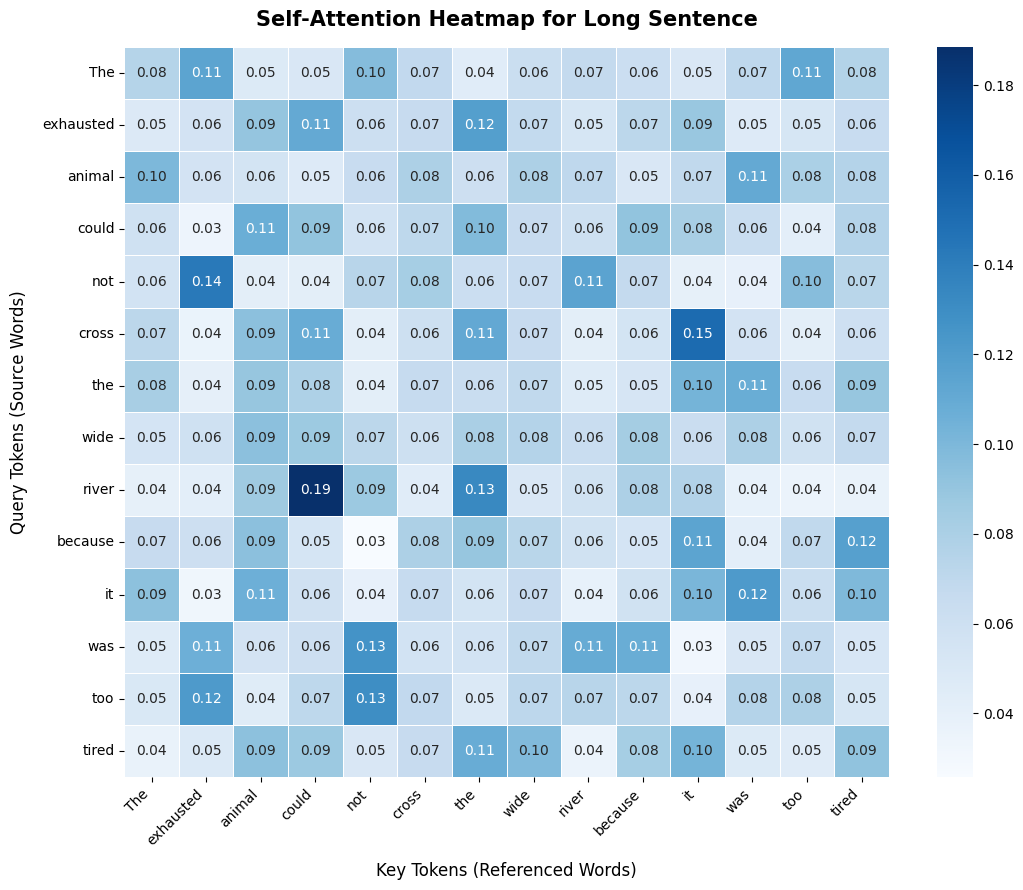

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define a longer realistic English sentence
sentence = "The exhausted animal could not cross the wide river because it was too tired"
tokens = sentence.split()
seq_len = len(tokens)
d_model = 16  # Increased embedding dimension for a longer sequence

# Fix random seed for reproducibility
torch.manual_seed(42)

# 2. Simulate input word embeddings (X) and weight matrices W^Q, W^K
X = torch.randn(1, seq_len, d_model)

W_Q = nn.Linear(d_model, d_model, bias=False)
W_K = nn.Linear(d_model, d_model, bias=False)

# 3. Compute Query, Key, and Scaled Dot-Product Attention
Q = W_Q(X)
K = W_K(X)

# Attention Score Calculation: (Q x K^T) / sqrt(d_k)
scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_model ** 0.5)

# Softmax across keys (rows sum to 1.0)
attention_weights = F.softmax(scores, dim=-1).squeeze(0).detach().numpy()

# 4. Plot the Attention Heatmap in English
plt.figure(figsize=(11, 9))
sns.heatmap(
    attention_weights,
    xticklabels=tokens,
    yticklabels=tokens,
    annot=True,      # Display numeric values inside cells
    fmt=".2f",       # Format numbers to 2 decimal places
    cmap="Blues",    # Blue color scale
    cbar=True,       # Display color bar
    linewidths=0.5   # Add grid lines between cells
)

# Set Title and Axis Labels in English
plt.title("Self-Attention Heatmap for Long Sentence", fontsize=15, pad=15, fontweight='bold')
plt.xlabel("Key Tokens (Referenced Words)", fontsize=12, labelpad=10)
plt.ylabel("Query Tokens (Source Words)", fontsize=12, labelpad=10)

# Rotate tick labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

### Hugging Face Example

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


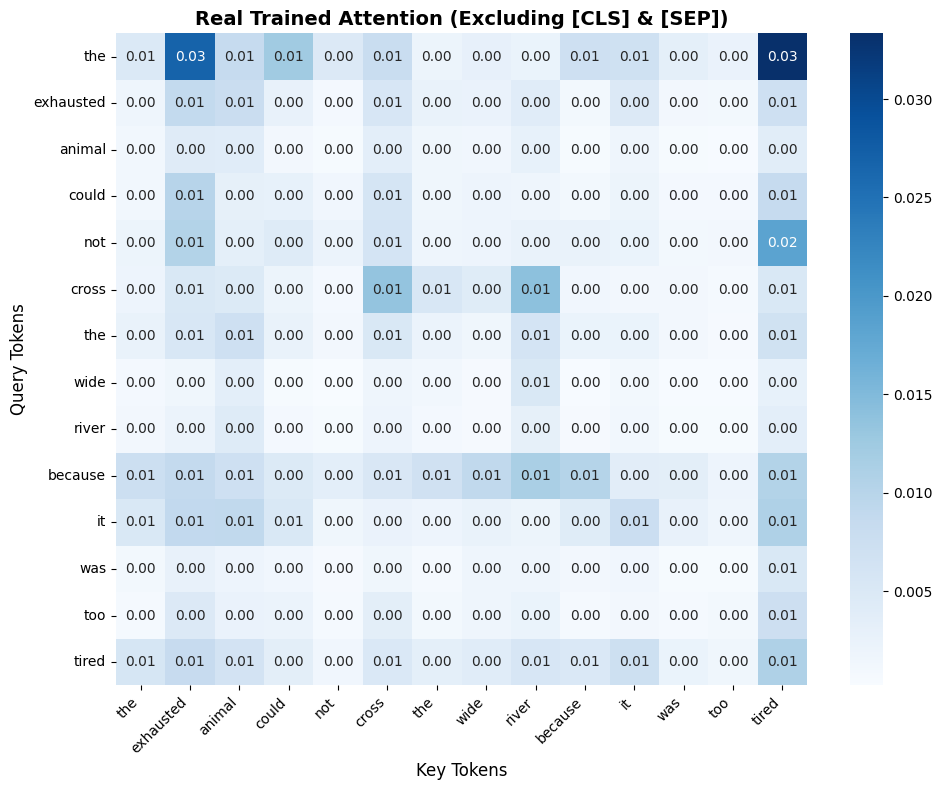

In [38]:
import torch
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 실제 학습된 BERT 모델과 토크나이저 로드
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)

# 2. 문장 입력 및 토크나이징
sentence = "The exhausted animal could not cross the wide river because it was too tired"
inputs = tokenizer(sentence, return_tensors="pt")
raw_tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

# 3. 모델 순전파 (어텐션 출력 추출)
with torch.no_grad():
    outputs = model(**inputs)
    attentions = outputs.attentions

# 마지막 레이어의 첫 번째 Head 어텐션 추출 (shape: seq_len x seq_len)
full_attention = attentions[-1][0, 0].numpy()

# ---------------------------------------------------------
# 4. [CLS]와 [SEP] 토큰 제거 (인덱스 슬라이싱)
# [CLS]는 맨 앞(index 0), [SEP]는 맨 뒤(index -1)에 위치함
# ---------------------------------------------------------
tokens = raw_tokens[1:-1]                     # 맨 앞/뒤 토큰 제외
clean_attention = full_attention[1:-1, 1:-1]  # 행/열 모두 슬라이싱

# 5. [CLS], [SEP]가 제거된 Attention Heatmap 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(
    clean_attention,
    xticklabels=tokens,
    yticklabels=tokens,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)
plt.title("Real Trained Attention (Excluding [CLS] & [SEP])", fontsize=14, fontweight='bold')
plt.xlabel("Key Tokens", fontsize=12)
plt.ylabel("Query Tokens", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()